In [1]:
import sys
sys.path.append(f"./../")

from src.static_graph import StaticGraph
import numpy as np
from scipy.linalg import expm
from qiskit.circuit.library import UnitaryGate
from qiskit.compiler import transpile


# 2 Qubit Graphs

### Graph 1

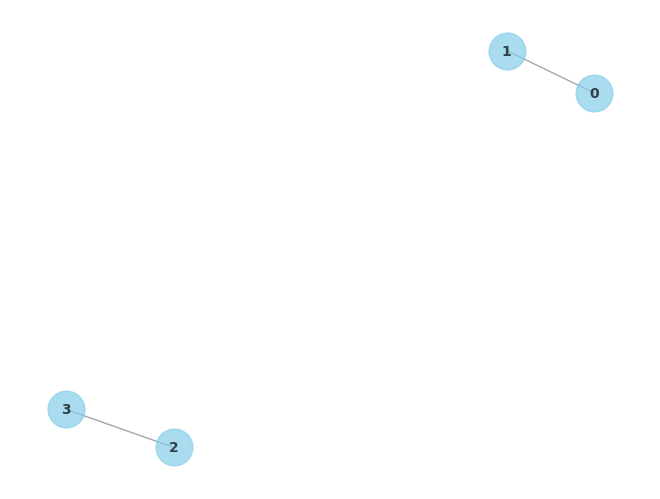

In [2]:
nodes = {0, 1, 2, 3}
edges = {(0, 1), (2, 3)}
G1 = StaticGraph(nodes, edges)
G1.draw()

In [3]:
adj_mat = G1.get_adj_mat()
t = np.pi/2
U = expm(-1j * adj_mat * t)
U = UnitaryGate(U)
qc = U.definition
qc = transpile(qc, basis_gates=['rx','ry','rz','cx'])
qc.draw(reverse_bits=True)

q0_1: ─────────
      ┌───────┐
q0_0: ┤ Rx(π) ├
      └───────┘

### Graph 2

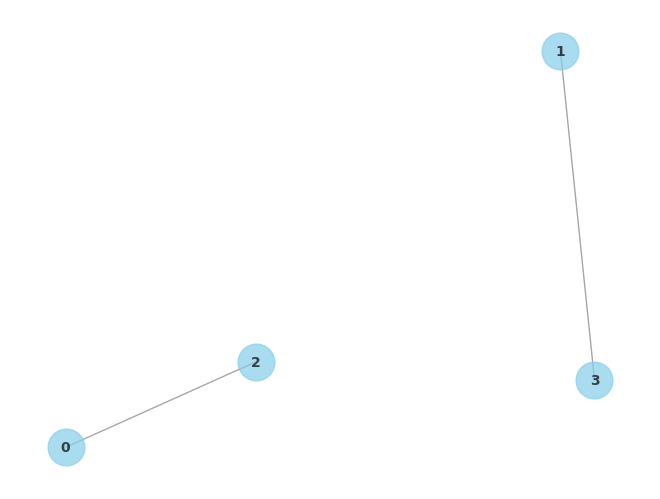

In [4]:
nodes = {0, 1, 2, 3}
edges = {(0, 2), (1, 3)}
G2 = StaticGraph(nodes, edges)
G2.draw()

In [5]:
adj_mat = G2.get_adj_mat()
t = np.pi/2
U = expm(-1j * adj_mat * t)
U = UnitaryGate(U)
qc = U.definition
qc = transpile(qc, basis_gates=['rx','ry','rz','cx'])
qc.draw(reverse_bits=True)

┌───────┐
q2_1: ┤ Rx(π) ├
      └───────┘
q2_0: ─────────

### Graph 3

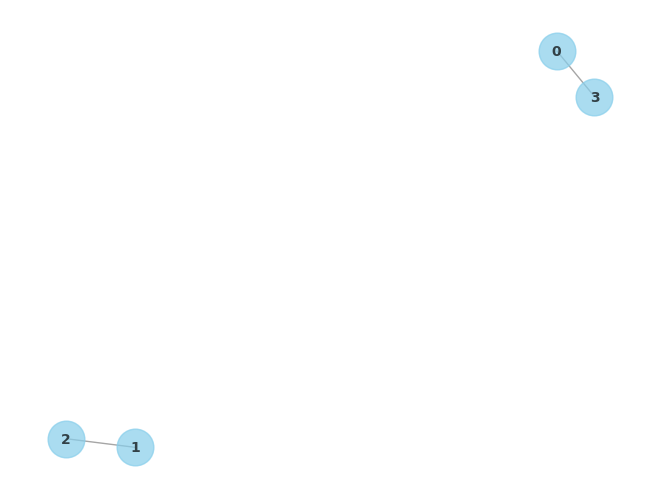

In [6]:
nodes = {0, 1, 2, 3}
edges = {(0, 3), (1, 2)}
G3 = StaticGraph(nodes, edges)
G3.draw()

In [7]:
adj_mat = G3.get_adj_mat()
t = np.pi/2
U = expm(-1j * adj_mat * t)
U = UnitaryGate(U)
qc = U.definition
qc = transpile(qc, basis_gates=['rx','ry','rz','cx'])
qc.draw(reverse_bits=True)

global phase: π/2
      ┌───────┐
q4_1: ┤ Rx(π) ├
      ├───────┤
q4_0: ┤ Rx(π) ├
      └───────┘

# 3 Qubit Graphs

In [8]:
from itertools import product

nodes = {0, 1, 2, 3, 4, 5, 6, 7}

# Create a set of all possible tuples from nodes excluding (x, x)
possible_tuples = [(x, y) for x, y in product(nodes, repeat=2) if x != y]

In [9]:
# Use a for loop to select two different tuples
for i in range(len(possible_tuples)):
    for j in range(i + 1, len(possible_tuples)):
        edges = {possible_tuples[i], possible_tuples[j]}
        print(f'edgs: {edges}')
        G = StaticGraph(nodes, edges)
        adj_mat = G.get_adj_mat()
        t = np.pi/2
        U = expm(-1j * adj_mat * t)
        U = UnitaryGate(U)
        qc = U.definition
        qc = transpile(qc, basis_gates=['x','y','z','h','t','s','rx','ry','rz','cx'], optimization_level=3)
        print('')
        print(qc.draw(reverse_bits=True, scale = 0.5))
        print('------------------------------------------------------------------------------')
        print('')
        print('')

edgs: {(0, 1), (0, 2)}

global phase: π
      ┌──────────┐   ┌────────┐  ┌───┐  ┌──────────┐ ┌─────────┐     »
q6_2: ┤ Ry(-π/2) ├───┤ Rz(-π) ├──┤ X ├──┤ Ry(-π/2) ├─┤ Rz(π/2) ├─────»
      └──────────┘   └────────┘  └─┬─┘┌─┴──────────┴┐└┬────────┤┌───┐»
q6_1: ─────────────────────────────■──┤ Rx(-2.1452) ├─┤ Rz(-π) ├┤ X ├»
      ┌──────────┐┌─────────────┐     └─────────────┘ └────────┘└─┬─┘»
q6_0: ┤ Rx(-π/2) ├┤ Rz(-4.1914) ├─────────────────────────────────■──»
      └──────────┘└─────────────┘                                    »
«                                                                      »
«q6_2: ────────────────────────────────────────────────────────────────»
«      ┌────────────┐┌────────────┐┌─────────────┐┌───┐┌──────────────┐»
«q6_1: ┤ Rz(1.6077) ├┤ Ry(1.6077) ├┤ Rz(-3.1402) ├┤ X ├┤ Rx(-0.74849) ├»
«      ├────────────┤└────────────┘└─────────────┘└─┬─┘├─────────────┬┘»
«q6_0: ┤ Ry(2.1884) ├───────────────────────────────■──┤ Rz(-2.3607) ├─»
«      └────────────┘    